In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [2]:
k = pd.read_csv("~/python_decal_fa25/course_assignments/homework9/solar_system.csv")

In [3]:
k

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
5,Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
6,Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
7,Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
8,Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8
9,Aphelion (10^6 km),69.8,108.9,152.1,0.406,249.3,816.4,1506.5,3001.4,4558.9,7375.9


In [5]:
k.shape # The shape of my dataset is (20,11)

(20, 11)

In [5]:
# There are 20 rows and 11 columns

In [6]:
k.head()

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3


In [7]:
k.tail()

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
15,Mean Temperature (C),167,464,15,-20,-65,-110,-140,-195,-200,-225
16,Surface Pressure (bars),0,92,1,0,0.01,Unknown,Unknown,Unknown,Unknown,0.00001
17,Number of Moons,0,0,1,0,2,95,274,28,16,5
18,Ring System?,No,No,No,No,No,Yes,Yes,Yes,Yes,No
19,Global Magnetic Field?,Yes,No,Yes,No,No,Yes,Yes,Yes,Yes,Unknown


In [8]:
k.columns

Index(['Attribute', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter',
       'Saturn', 'Uranus', 'Neptune', 'Pluto'],
      dtype='object')

In [9]:
print(k['Attribute'])

0                  Mass (10^24kg)
1                   Diameter (km)
2                Density (kg/m^3)
3                 Gravity (m/s^2)
4          Escape Velocity (km/s)
5         Rotation Period (hours)
6           Length of Day (hours)
7     Distance from Sun (10^6 km)
8            Perihelion (10^6 km)
9              Aphelion (10^6 km)
10          Orbital Period (days)
11        Orbital Velocity (km/s)
12      Orbital Inclination (deg)
13           Orbital Eccentricity
14       Obliquity to Orbit (deg)
15           Mean Temperature (C)
16        Surface Pressure (bars)
17                Number of Moons
18                   Ring System?
19         Global Magnetic Field?
Name: Attribute, dtype: object


In [32]:
z = k.iloc[10, 1:].astype(float)

z

Mercury       88.0
Venus        224.7
Earth        365.2
Moon          27.3
Mars         687.0
Jupiter     4331.0
Saturn     10747.0
Uranus     30589.0
Neptune    59800.0
Pluto      90560.0
Name: 10, dtype: float64

In [33]:
perihelion = k.iloc[8, 1:].astype(float)
perihelion

Mercury      46.000
Venus       107.500
Earth       147.100
Moon          0.363
Mars        206.700
Jupiter     740.600
Saturn     1357.600
Uranus     2732.700
Neptune    4471.100
Pluto      4436.800
Name: 8, dtype: float64

In [34]:
aphelion = k.iloc[9, 1:].astype(float)
aphelion

Mercury      69.800
Venus       108.900
Earth       152.100
Moon          0.406
Mars        249.300
Jupiter     816.400
Saturn     1506.500
Uranus     3001.400
Neptune    4558.900
Pluto      7375.900
Name: 9, dtype: float64

In [17]:
# Perihelion is the point in a planet's orbit where it's moving the fastest, it is closest
# to the focus that the Sun is at

# Aphelion is when the planet is moving slowest and is closest to the focus away from the
# Sun in the orbit

# The semi-major axis is the distance from the furthest points on the ecliptic to the center
# of the ellipse.

In [87]:
semi_major_axis = (perihelion + aphelion) / 2

semi_major_axis

Mercury      57.9000
Venus       108.2000
Earth       149.6000
Moon          0.3845
Mars        228.0000
Jupiter     778.5000
Saturn     1432.0500
Uranus     2867.0500
Neptune    4515.0000
Pluto      5906.3500
dtype: float64

In [110]:
j = pd.DataFrame([semi_major_axis])

j["Attribute"] = "Semi-Major Axis (10^6 km)"

j

,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto,Attribute
0,57.9,108.2,149.6,0.3845,228.0,778.5,1432.05,2867.05,4515.0,5906.35,Semi-Major Axis (10^6 km)


In [99]:
i = pd.concat([k,j], axis=0, ignore_index=True)

i

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
0,Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
1,Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
2,Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
3,Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
4,Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
5,Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
6,Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
7,Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
8,Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8
9,Aphelion (10^6 km),69.8,108.9,152.1,0.406,249.3,816.4,1506.5,3001.4,4558.9,7375.9


In [101]:
i.shape # it is now 21 rows and 11 columns)

(21, 11)

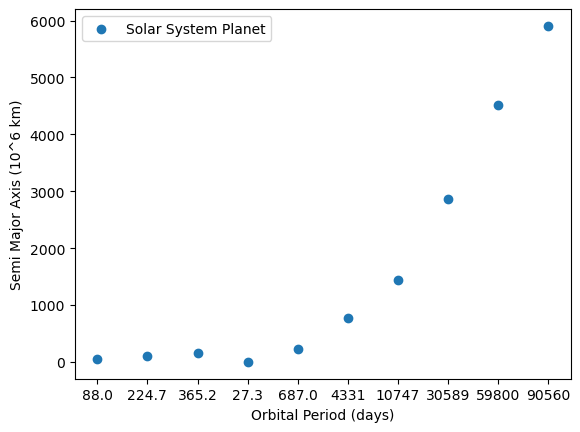

In [118]:
plt.figure()

plt.scatter(i.iloc[10, 1:], i.iloc[20, 1:], label='Solar System Planet')

plt.xlabel('Orbital Period (days)')

plt.ylabel('Semi Major Axis (10^6 km)')

plt.legend()

plt.show()



In [140]:
def keplers_third_law(a,m):
    return m * a ** 1.5

popt, pcov = curve_fit(keplers_third_law, i.iloc[20, 1:], i.iloc[10, 1:])



str

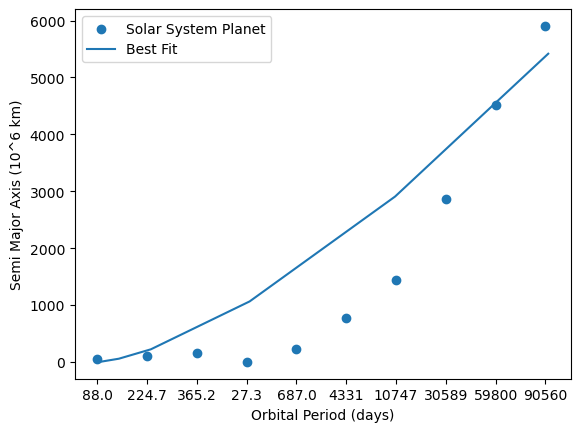

In [191]:
x = i.iloc[10, 1:]

y = i.iloc[20, 1:]

plt.figure()

plt.scatter(i.iloc[10, 1:], i.iloc[20, 1:], label='Solar System Planet')

plt.plot(x.astype(float) * 10 ** -4, keplers_third_law(x.astype(float), popt) * 10 ** -3, label='Best Fit')

plt.xlabel('Orbital Period (days)')

plt.ylabel('Semi Major Axis (10^6 km)')

plt.legend()

plt.show()

In [188]:
print(popt[0])

0.19879981918623565


In [186]:
print(f"Curve of Best Fit: {popt[0]:.2f} * a ** 1.5")

Curve of Best Fit: 0.20 * a ** 1.5


In [192]:
residuals = y - keplers_third_law(x.astype(float), popt)

In [193]:
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_squared = chi2/dof

In [194]:
print(f"Reduced Chi Squared: {chi2_squared:.2f}")

Reduced Chi Squared: 4321135075414.40


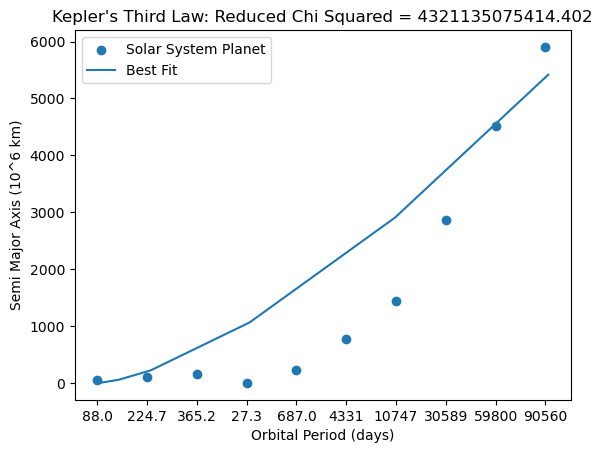

In [195]:
x = i.iloc[10, 1:]

y = i.iloc[20, 1:]

plt.figure()

plt.scatter(i.iloc[10, 1:], i.iloc[20, 1:], label='Solar System Planet')

plt.plot(x.astype(float) * 10 ** -4, keplers_third_law(x.astype(float), popt) * 10 ** -3, label='Best Fit')

plt.title(f"Kepler's Third Law: Reduced Chi Squared = {chi2_squared}")

plt.xlabel('Orbital Period (days)')

plt.ylabel('Semi Major Axis (10^6 km)')

plt.legend()

plt.show()

In [197]:
i.to_csv("kepler.csv")

TypeError: NDFrame.to_csv() got an unexpected keyword argument 'ignore_index'